📊 SCREENSENSE: KIDS' SCREENTIME VISUALIZATION

✅ WEEK 1 INSIGHTS (Data Understanding & Cleaning)

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv(r"C:\Users\kanna\OneDrive\Desktop\Kids ScreenTime Visualization\Indian_Kids_Screen_Time.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [65]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [66]:
df.shape

(9712, 8)

In [67]:
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [69]:
df.duplicated().sum()

44

In [70]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [71]:
df = df.drop_duplicates()
print("Duplicates removed ✅")

Duplicates removed ✅


In [72]:
# Fill missing age with median
if 'age' in df.columns:
    df['age'].fillna(df['age'].median(), inplace=True)

# Drop rows if screentime is missing
if 'daily_hours' in df.columns:
    df = df.dropna(subset=['daily_hours'])

print("Missing values handled ✅")

Missing values handled ✅


In [73]:
# Convert categorical columns to lowercase and strip spaces
categorical_cols = ['gender', 'location_type', 'device_type', 'activity_category']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].str.lower().str.strip()

print("Categories standardized ✅")

Categories standardized ✅


In [74]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    print("Date column formatted ✅")

In [75]:
df.columns = df.columns.str.strip().str.lower()

In [76]:
print(df.columns)

Index(['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device',
       'exceeded_recommended_limit', 'educational_to_recreational_ratio',
       'health_impacts', 'urban_or_rural'],
      dtype='object')


⚙️ ✅ WEEK 2 INSIGHTS (Feature Engineering / Derived Columns)

In [77]:
df['age_band'] = pd.cut(
    df['age'],
    bins=[0,5,10,13,18],
    labels=[
        '0-5 (Early Childhood)',
        '6-10 (Primary)',
        '11-13 (Middle)',
        '14-18 (Teen)'
    ]
)

In [78]:
df['usage_level'] = pd.cut(
    df['avg_daily_screen_time_hr'],
    bins=[0,2,5,24],
    labels=['Low Usage','Moderate Usage','High Usage']
)

In [79]:
df['risk_category'] = pd.cut(
    df['avg_daily_screen_time_hr'],
    bins=[0,3,6,24],
    labels=['Safe','Watch','Risk']
)

In [80]:
df['is_heavy_user'] = df['avg_daily_screen_time_hr'] > 5

In [81]:
max_hours = df['avg_daily_screen_time_hr'].max()

df['dependency_index'] = df['avg_daily_screen_time_hr'] / max_hours

In [82]:
df['device_popularity'] = df.groupby('primary_device')['primary_device'].transform('count')

In [83]:
df['learning_type'] = df['educational_to_recreational_ratio'].apply(
    lambda x: 'More Educational' if x >= 0.5 else 'More Recreational'
)

In [84]:
df['urban_usage_flag'] = (
    (df['urban_or_rural'] == 'Urban') & 
    (df['avg_daily_screen_time_hr'] > 5)
)

📊 ✅ WEEK 3: Visual Exploration Insights

(Univariate & Bivariate Analysis)

🔵  UNIVARIATE ANALYSIS

✅ Single Numerical Variable

In [85]:
df['avg_daily_screen_time_hr'].describe()

count    9668.000000
mean        4.367780
std         1.703002
min         0.000000
25%         3.427500
50%         4.440000
75%         5.380000
max        13.890000
Name: avg_daily_screen_time_hr, dtype: float64

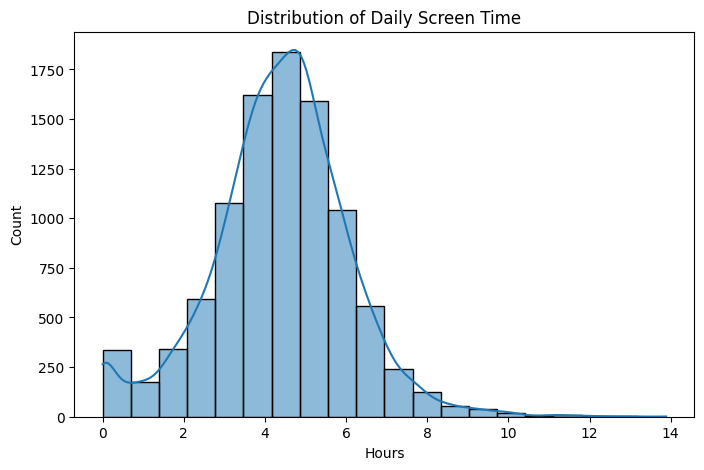

In [86]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_daily_screen_time_hr'], bins=20, kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

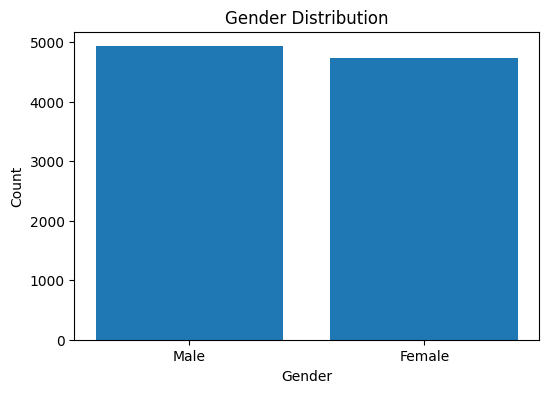

In [87]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts.values)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

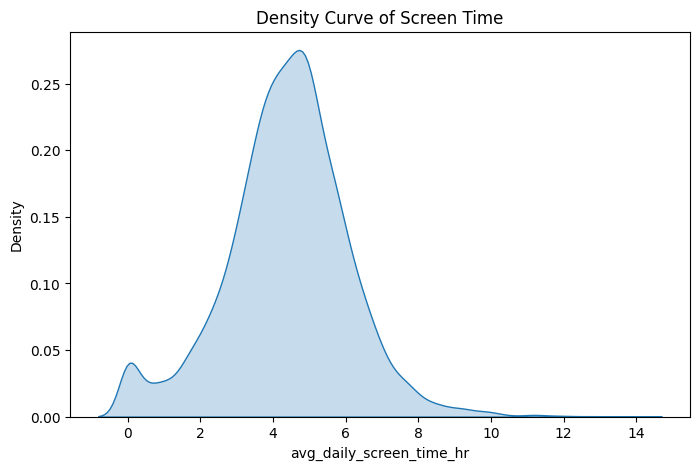

In [88]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['avg_daily_screen_time_hr'], fill=True)
plt.title("Density Curve of Screen Time")
plt.show()

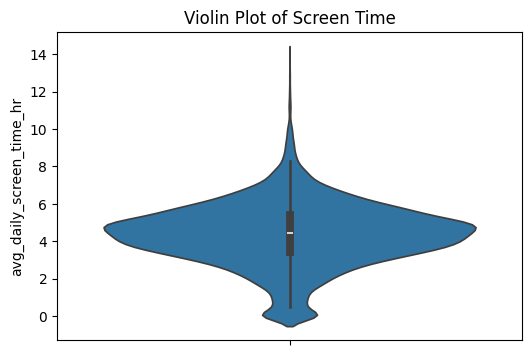

In [89]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df['avg_daily_screen_time_hr'])
plt.title("Violin Plot of Screen Time")
plt.show()

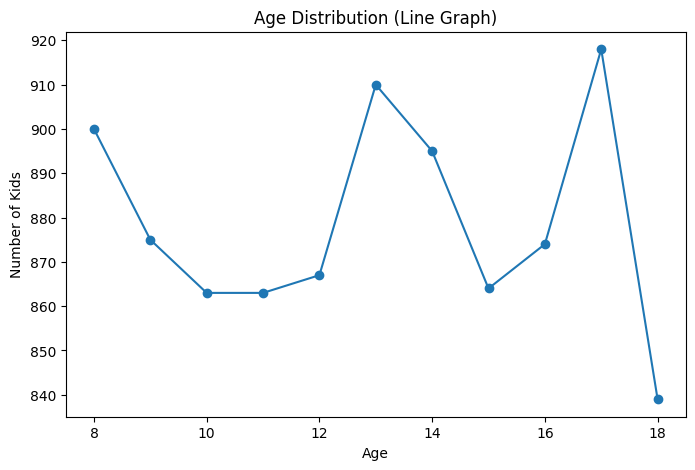

In [90]:
# Count frequency of each age
age_counts = df['age'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(age_counts.index, age_counts.values, marker='o')
plt.title("Age Distribution (Line Graph)")
plt.xlabel("Age")
plt.ylabel("Number of Kids")
plt.show()


2️⃣ SINGLE CATEGORICAL

In [91]:
df['primary_device'].value_counts()


primary_device
Smartphone    4540
TV            2478
Laptop        1431
Tablet        1219
Name: count, dtype: int64

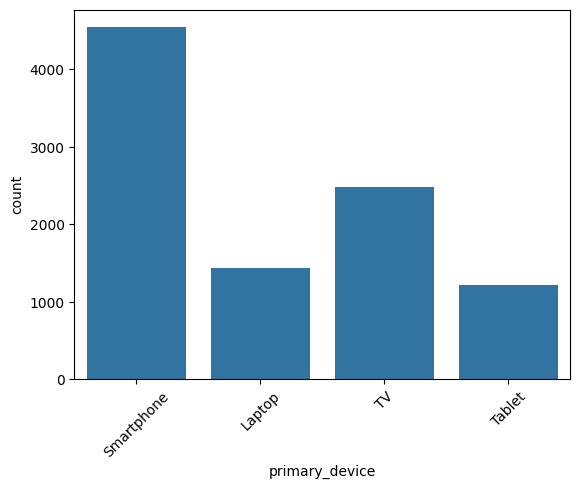

In [92]:
sns.countplot(x='primary_device', data=df)
plt.xticks(rotation=45)
plt.show()

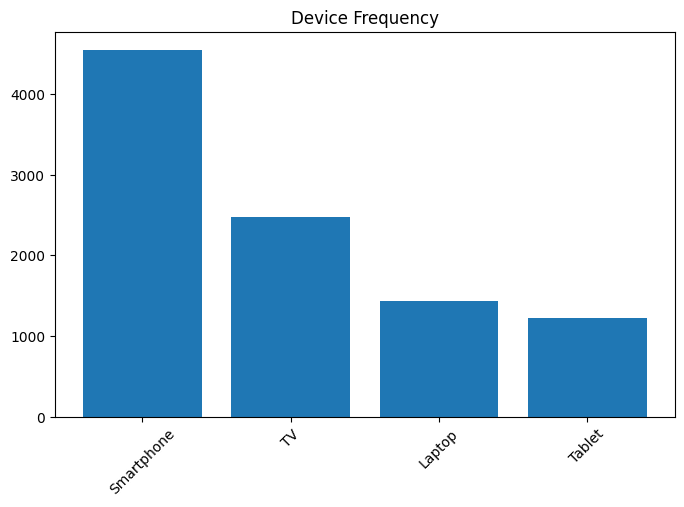

In [93]:
device_counts = df['primary_device'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(device_counts.index, device_counts.values)
plt.xticks(rotation=45)
plt.title("Device Frequency")
plt.show()

In [94]:
df['age_band'] = pd.cut(
    df['age'],
    bins=[0,5,10,13,18],
    labels=['0-5','6-10','11-13','14-18']
)


In [95]:
age_counts = df['age_band'].value_counts()

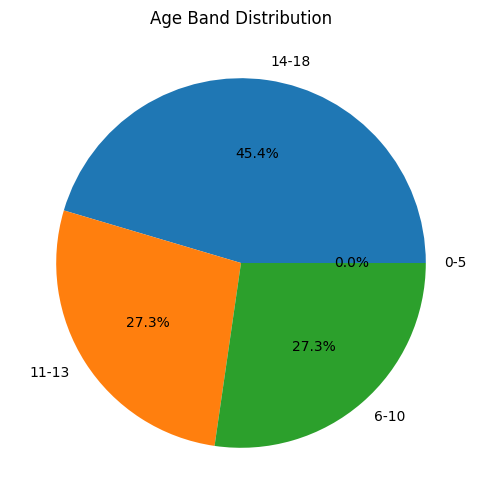

In [96]:
plt.figure(figsize=(6,6))
plt.pie(age_counts,
        labels=age_counts.index,
        autopct='%1.1f%%')
plt.title("Age Band Distribution")
plt.show()

In [97]:
gender_counts = df['gender'].value_counts()

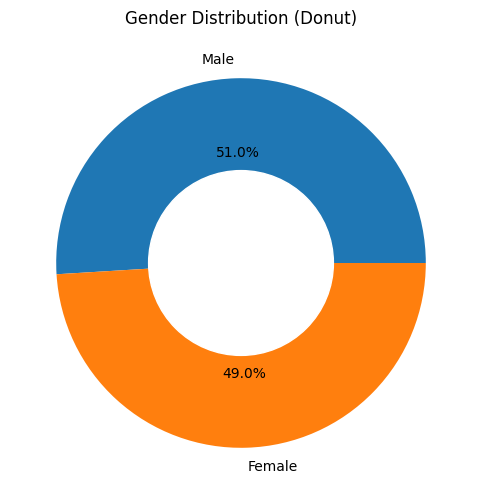

In [98]:
plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%')

circle = plt.Circle((0,0),0.5,color='white')
plt.gca().add_artist(circle)

plt.title("Gender Distribution (Donut)")
plt.show()

🎯 BIVARIATE ANALYSIS

1️⃣ Numerical vs Categorical

✅Screen Time by Gender

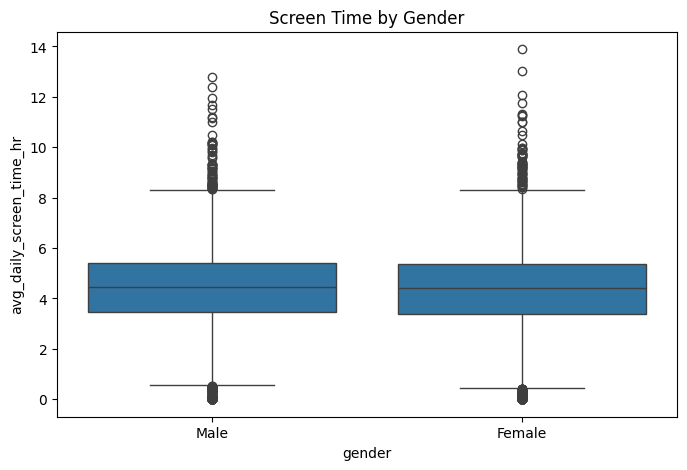

In [99]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender',
            y='avg_daily_screen_time_hr',
            data=df)
plt.title("Screen Time by Gender")
plt.show()

✅ Screen Time by Urban vs Rural

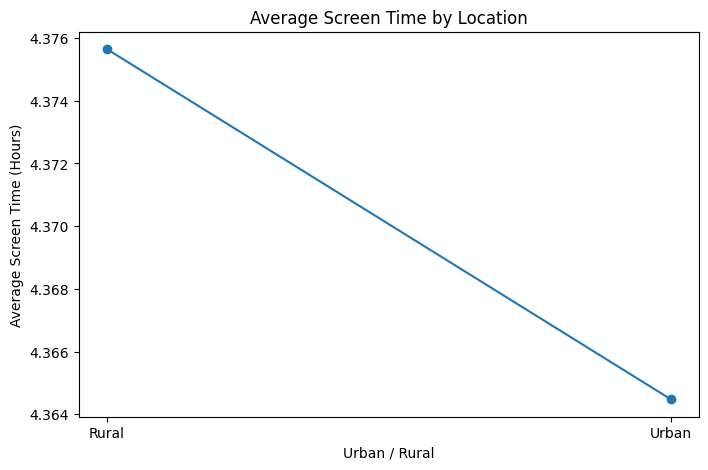

In [100]:
urban_mean = df.groupby('urban_or_rural')['avg_daily_screen_time_hr'].mean().sort_index()

plt.figure(figsize=(8,5))
plt.plot(urban_mean.index, urban_mean.values, marker='o', linestyle='-')

plt.title("Average Screen Time by Location")
plt.xlabel("Urban / Rural")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

✅ Screen Time by Device

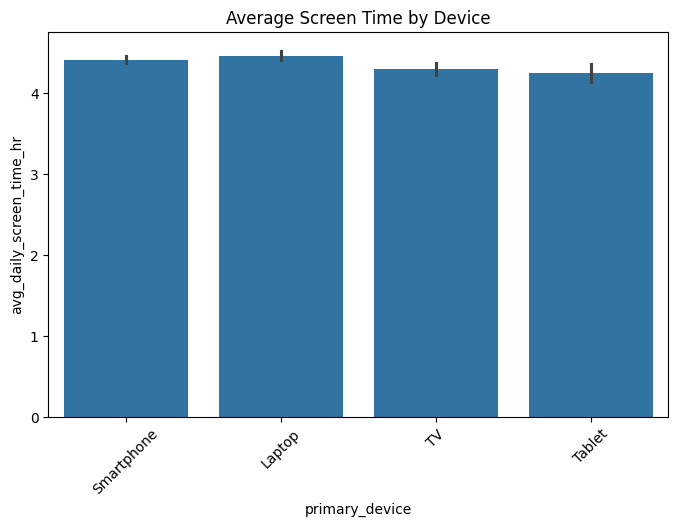

In [101]:
plt.figure(figsize=(8,5))
sns.barplot(x='primary_device',
            y='avg_daily_screen_time_hr',
            data=df)
plt.xticks(rotation=45)
plt.title("Average Screen Time by Device")
plt.show()

✅Screen Time by Age Band

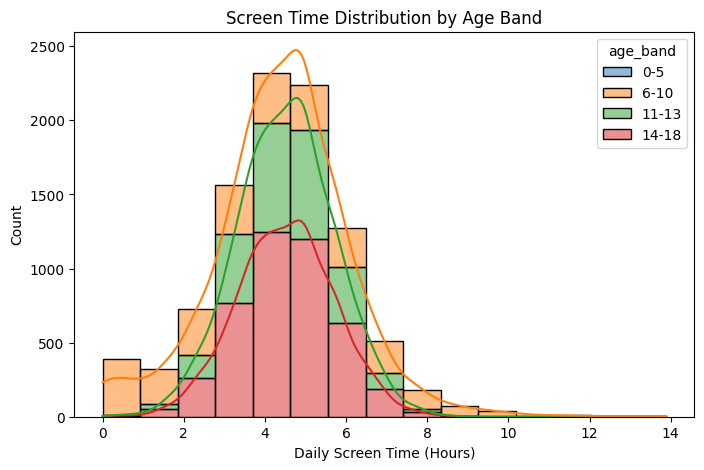

In [102]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x='avg_daily_screen_time_hr',
             hue='age_band',
             bins=15,
             kde=True,
             multiple='stack')

plt.title("Screen Time Distribution by Age Band")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Count")

plt.show()

✅ Screen Time by Health Impacts

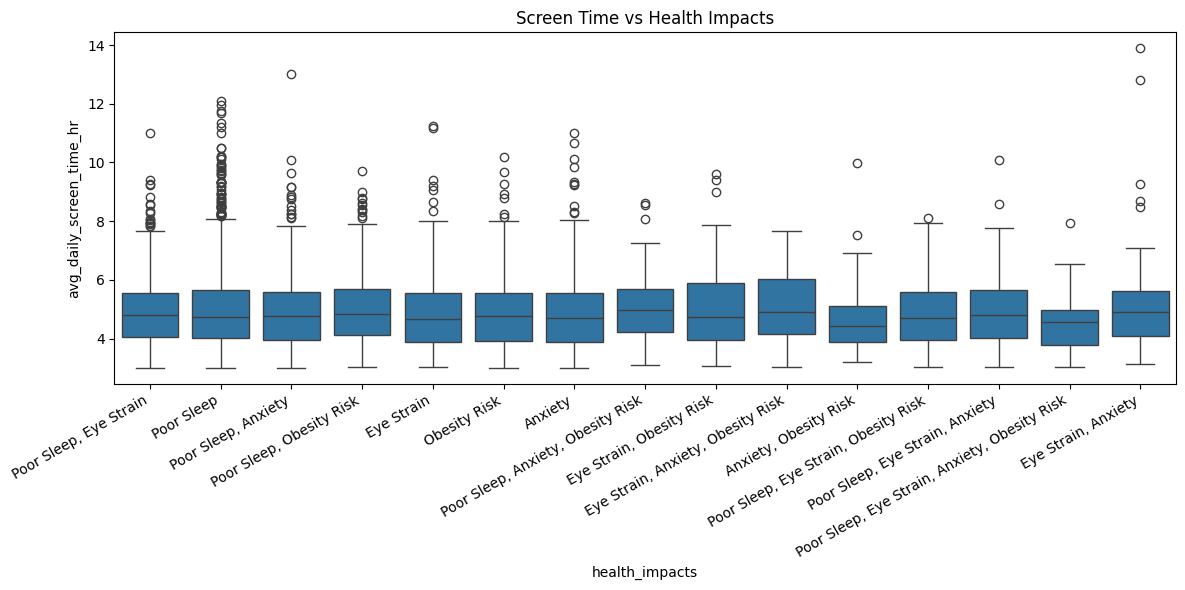

In [103]:
plt.figure(figsize=(12,6))

sns.boxplot(x='health_impacts',
            y='avg_daily_screen_time_hr',
            data=df)

plt.xticks(rotation=30, ha='right')   # rotate slightly
plt.title("Screen Time vs Health Impacts")
plt.tight_layout()   # prevents cut-off

plt.show()


2️⃣ Numerical vs Numerical

✅ Age vs Screen Time Trend

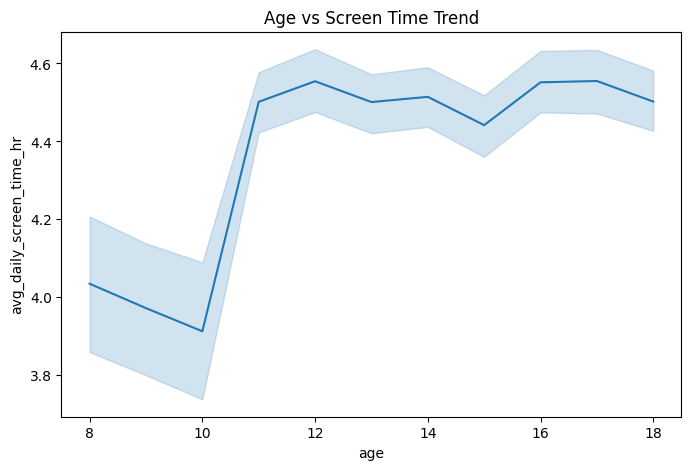

In [104]:
plt.figure(figsize=(8,5))
sns.lineplot(x='age',
             y='avg_daily_screen_time_hr',
             data=df)
plt.title("Age vs Screen Time Trend")
plt.show()

✅ Educational Ratio vs Screen Time

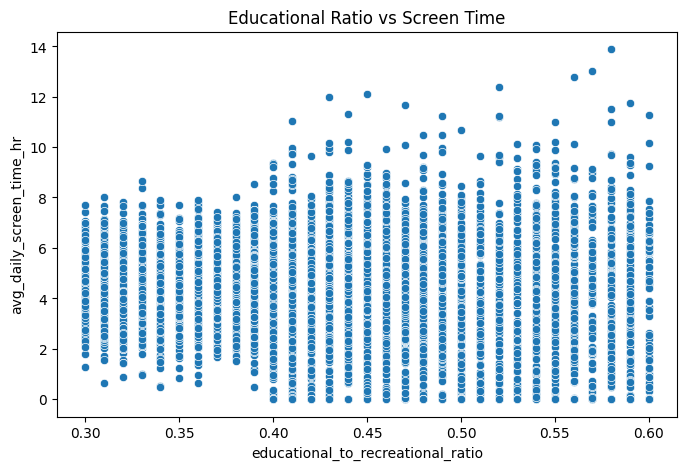

In [105]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='educational_to_recreational_ratio',
                y='avg_daily_screen_time_hr',
                data=df)
plt.title("Educational Ratio vs Screen Time")
plt.show()


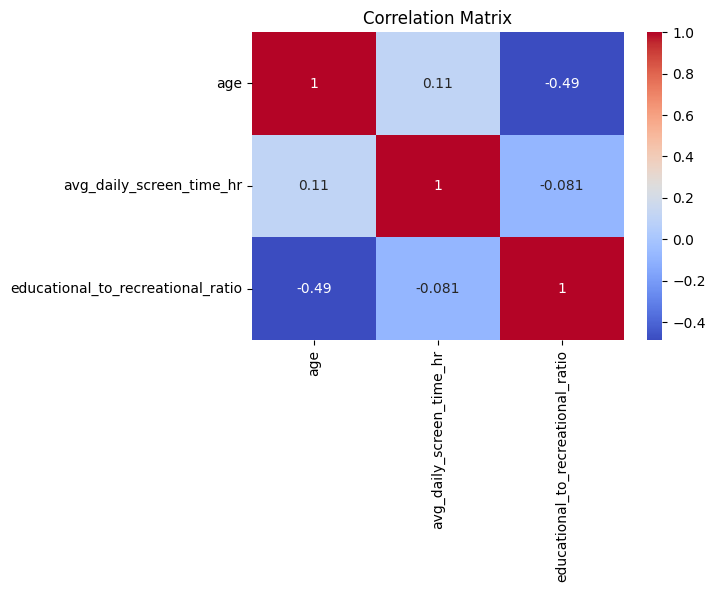

In [106]:
plt.figure(figsize=(6,4))
corr = df[['age',
           'avg_daily_screen_time_hr',
           'educational_to_recreational_ratio']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

3️⃣ Categorical vs Categorical

✅ Gender vs Device

In [107]:
pd.crosstab(df['gender'], df['primary_device'])

primary_device,Laptop,Smartphone,TV,Tablet
gender,,,,
Female,739,2201,1213,587
Male,692,2339,1265,632


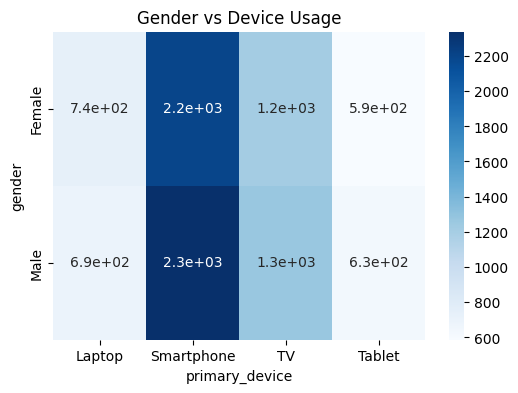

In [108]:
plt.figure(figsize=(6,4))
sns.heatmap(
    pd.crosstab(df['gender'], df['primary_device']),
    annot=True,
    cmap='Blues'
)
plt.title("Gender vs Device Usage")
plt.show()

✅ Urban vs Health Impacts

In [109]:
pd.crosstab(df['urban_or_rural'], df['health_impacts'])

health_impacts,Anxiety,"Anxiety, Obesity Risk",Eye Strain,"Eye Strain, Anxiety","Eye Strain, Anxiety, Obesity Risk","Eye Strain, Obesity Risk",Obesity Risk,Poor Sleep,"Poor Sleep, Anxiety","Poor Sleep, Anxiety, Obesity Risk","Poor Sleep, Eye Strain","Poor Sleep, Eye Strain, Anxiety","Poor Sleep, Eye Strain, Anxiety, Obesity Risk","Poor Sleep, Eye Strain, Obesity Risk","Poor Sleep, Obesity Risk"
urban_or_rural,,,,,,,,,,,,,,,
Rural,117,20,189,30,14,25,75,654,192,17,286,79,14,57,129
Urban,268,49,455,105,21,81,177,1610,415,61,692,179,23,131,323


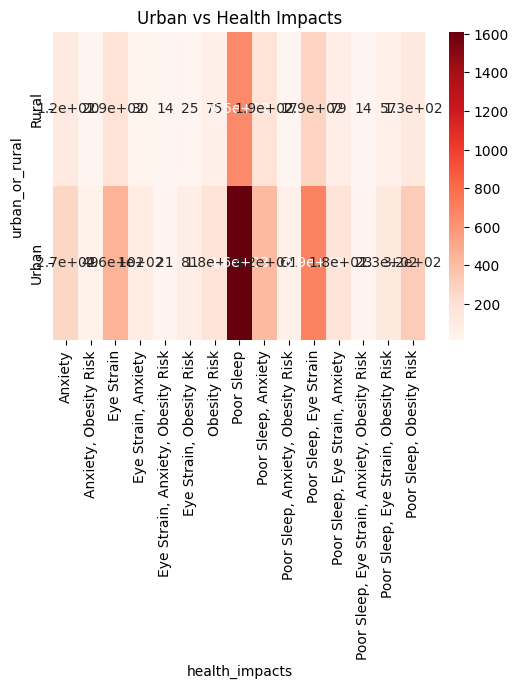

In [110]:
plt.figure(figsize=(6,4))
sns.heatmap(
    pd.crosstab(df['urban_or_rural'], df['health_impacts']),
    annot=True,
    cmap='Reds'
)
plt.title("Urban vs Health Impacts")
plt.show()


📊 Numerical vs Categorical

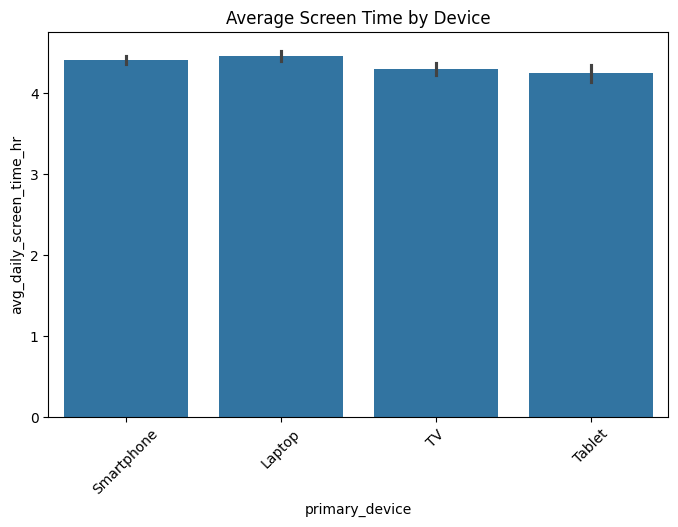

In [111]:
plt.figure(figsize=(8,5))
sns.barplot(x='primary_device',
            y='avg_daily_screen_time_hr',
            data=df)

plt.xticks(rotation=45)
plt.title("Average Screen Time by Device")
plt.show()


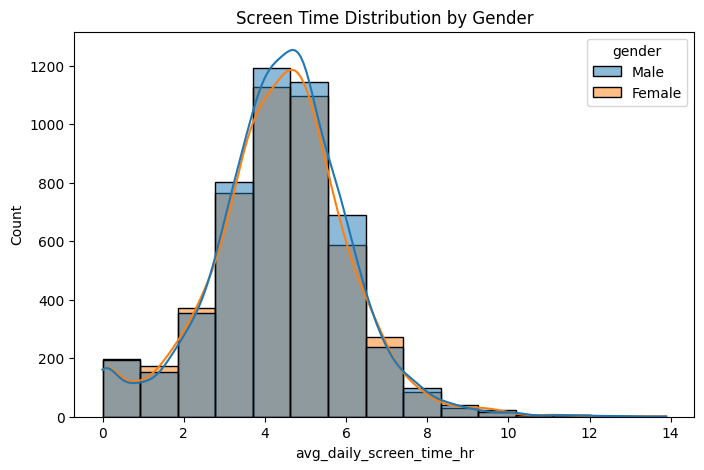

In [112]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,
             x='avg_daily_screen_time_hr',
             hue='gender',
             bins=15,
             kde=True)

plt.title("Screen Time Distribution by Gender")
plt.show()

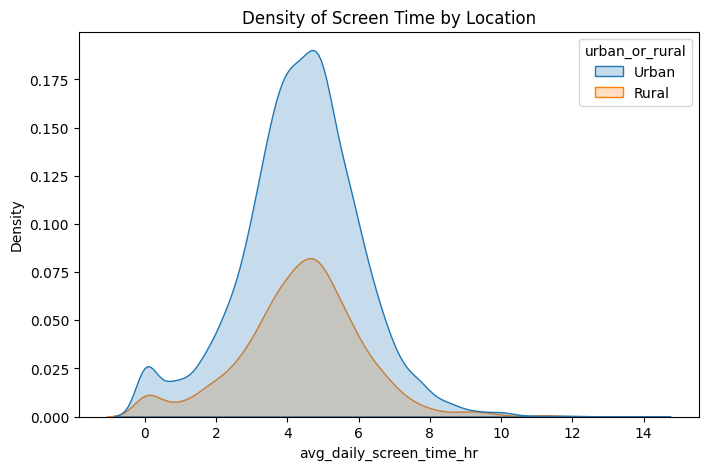

In [113]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,
            x='avg_daily_screen_time_hr',
            hue='urban_or_rural',
            fill=True)

plt.title("Density of Screen Time by Location")
plt.show()

🔵 Categorical vs Numerical

✅ Device vs Average Screen Time

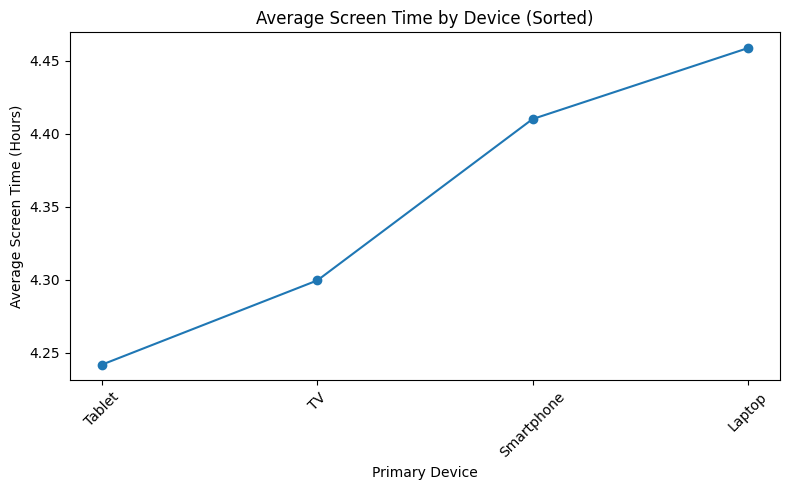

In [114]:
device_mean = df.groupby('primary_device')['avg_daily_screen_time_hr'].mean().sort_values()

plt.figure(figsize=(8,5))

plt.plot(device_mean.index,
         device_mean.values,
         marker='o')

plt.title("Average Screen Time by Device (Sorted)")
plt.xlabel("Primary Device")
plt.ylabel("Average Screen Time (Hours)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

📊 ✅ WEEK 4: Device & Habit Pattern Insights

(Cohort + Behavioral Analysis)

In [115]:
import numpy as np

df['day_type'] = np.random.choice(['Weekday','Weekend'], size=len(df))

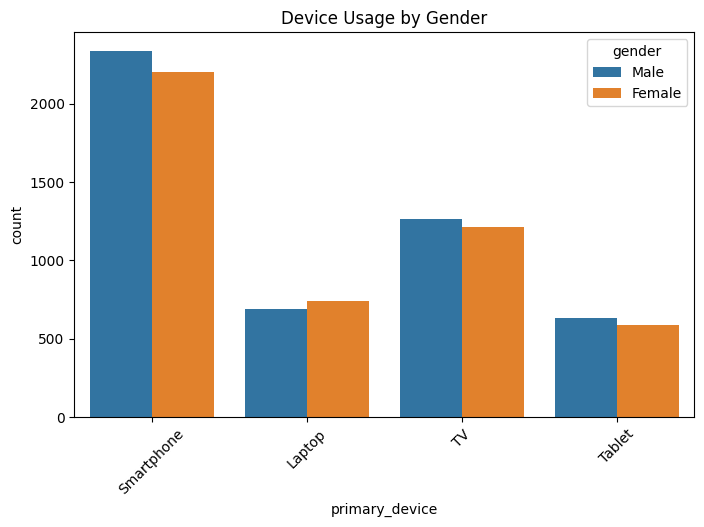

In [116]:
plt.figure(figsize=(8,5))

sns.countplot(x='primary_device',
              hue='gender',
              data=df)

plt.title("Device Usage by Gender")
plt.xticks(rotation=45)

plt.show()

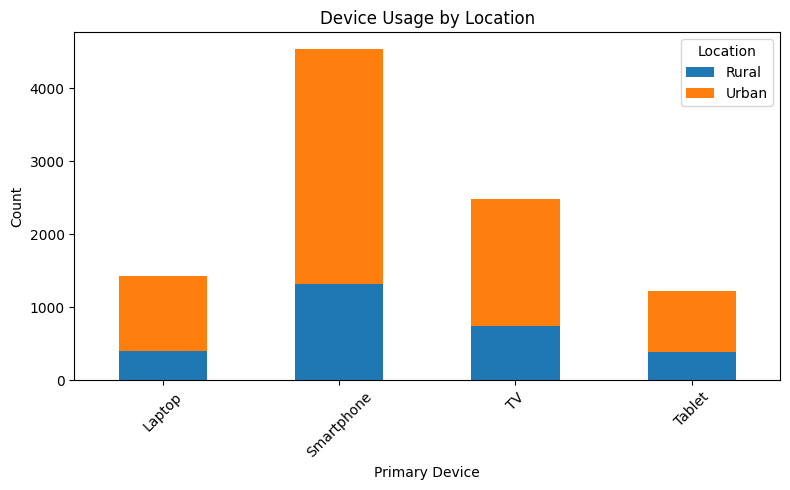

In [117]:
device_location = pd.crosstab(df['primary_device'], df['urban_or_rural'])

device_location.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Device Usage by Location")
plt.xlabel("Primary Device")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.legend(title="Location")

plt.tight_layout()
plt.show()

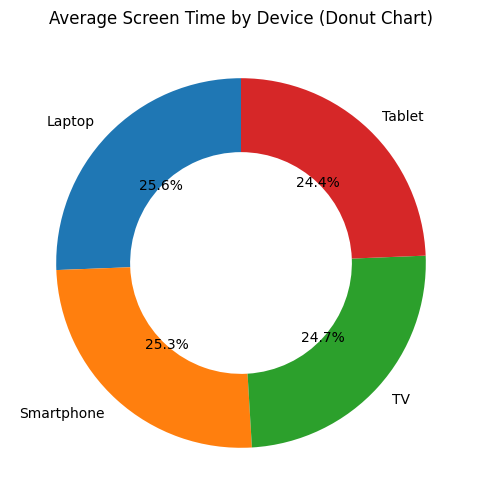

In [118]:
device_mean = df.groupby('primary_device')['avg_daily_screen_time_hr'].mean()

plt.figure(figsize=(6,6))

plt.pie(device_mean,
        labels=device_mean.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width':0.4})

plt.title("Average Screen Time by Device (Donut Chart)")

plt.show()


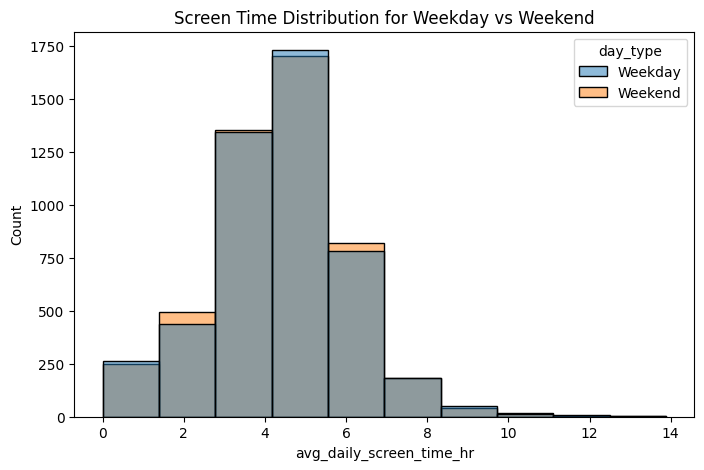

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x='avg_daily_screen_time_hr',
             hue='day_type',
             bins=10)

plt.title("Screen Time Distribution for Weekday vs Weekend")

plt.show()


C:\Users\kanna\AppData\Local\Temp\ipykernel_24236\1467579202.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_mean = df.groupby('age_band')['avg_daily_screen_time_hr'].mean()


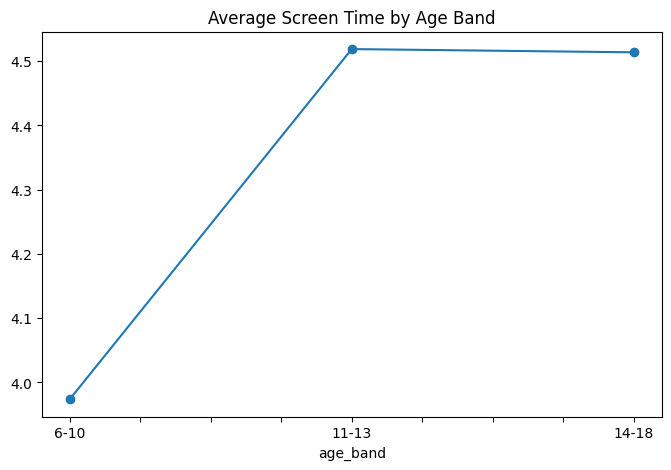

In [120]:
age_mean = df.groupby('age_band')['avg_daily_screen_time_hr'].mean()

plt.figure(figsize=(8,5))

age_mean.plot(kind='line', marker='o')

plt.title("Average Screen Time by Age Band")

plt.show()


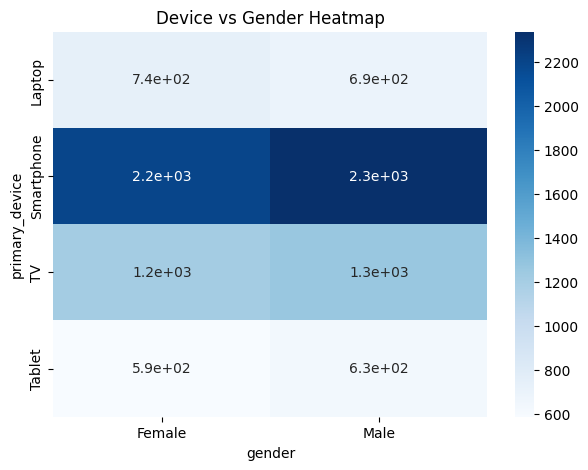

In [121]:
plt.figure(figsize=(7,5))

device_gender = pd.crosstab(df['primary_device'], df['gender'])

sns.heatmap(device_gender,
            annot=True,
            cmap='Blues')

plt.title("Device vs Gender Heatmap")

plt.show()

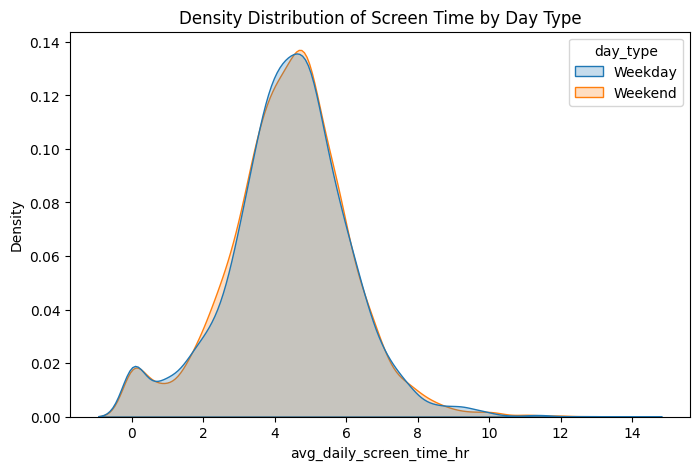

In [122]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df,
            x='avg_daily_screen_time_hr',
            hue='day_type',
            fill=True)

plt.title("Density Distribution of Screen Time by Day Type")

plt.show()
